# Summary

Welcome to my speaker design theory notebook! The goal of this notebook is to derive the speaker response equations from the definitions of the Thiele-Small parameters and basic electromechanical laws.

I will update this article as I make corrections and learn new things.

**How to read this notebook**: At first glance, it might be hard to tell what this "notebook" is. Is it an article? Is it a computer program? The answer to both questions is: Yes.

This notebook uses **jupyter**, which is a framework for creating notebooks that combine text, program code, and results, in a single document. It's like a lab notebook that can do things. Some people have begun using jupyter to create articles, by hiding the code, leaving just the text and results. That would make it look more like a textbook or research paper, but I prefer to leave my code out in the open for all to see. It shows what I actually did.

To make it a bit more complicated, all of my calculations will be done using **sympy**, the symbolic algebra package for Python. As a result, I've hopefully minimized my chance of making mistakes in long drawn-out derivations.

A drawback of **sympy** and most other computer algebra tools, is that they don't necessarily preserve the ordering of symbols, thus it's hard to enforce good notational conventions. The expressions will be harder to read than ones entered by hand.

**For casual reading**, skim past the equations and program code, and just read the text.

**For deeper reading**, follow the equations, but understand that they're just points along the way as I guide **sympy** towards a complete model of a speaker.

# Background

Thiele-Small theory has been around for a long time. Thiele's 1963 paper scan be found online:

[Thiele 1963 paper, part 1](https://pearl-hifi.com/06_Lit_Archive/14_Books_Tech_Papers/Thiele_Neville/Thiele-Loudspeakers-in-Vented-Boxes-Parts-I_II.pdf)

[Thiele 1963 paper, part 2](https://diyaudioprojects.com/Technical/Papers/Vented-Box-Loudspeaker-Systems-Part-II.pdf)

Thiele's paper uses a lumped element model, where terms of coupled differential equations are shown graphically as resistors, capacitors, etc. The "wires" in the graph represent the couplings. *I am deriving essentially the same theory* but expressing the differential equations in algebraic form. This is easier for me to understand, and results in formulas that can be translated directly into computer code.

Thiel-Small theory is the basis for virtually all of the freely available speaker design programs. I've checked the result of my calculations against popular programs, though the accuracy of those programs is not uncontroversial -- especially regarding the port dimensions. But my point is that this is not "my" theory, but is a representation of mainstream theory, to the best of my understanding.

# Limitations of the theory

1. Small signal levels, meaning that the behavior of the speaker is linear. This avoids dealing with the excursion limit, and with the harmonic distortion generated by nonlinear compression of the air in the box.

2. Low frequencies, up to maybe 250 Hz, give or take. Above those frequencies, off-axis response becomes important, and for full-range drivers, the flexibility of the cone affects the response curve. But higher frequencies are also not affected much by box design, so you can fill them in using the graphs that vendors provide for their drivers.

3. On-axis response only. At higher frequencies, the angular dependence of the response curve becomes important. There are formulas for dealing with off-axis response elsewhere.

# Units of measure

Everything is SI. If you want to make use of my formulas, you have to get your design parameters into SI units.

In [53]:
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np
from IPython.display import display, Math
import copy
import pandas as pd
pd.set_option('display.precision', 3)

def displayEq(sym, expr):
    '''
    Helper function to display an expression as an equation for readability
    '''
    if __name__ == '__main__':
        display(Math(sym + ' = ' + sp.latex(expr)))

**Sympy** needs to have all symbols defined. I'm putting them all in one place, to keep them from cluttering the rest of the notebook.

In [54]:
x, v, a, X = sp.symbols('x v a X')
V = sp.symbols('V', real = True)
V_in, omega, t, f, P_in = sp.symbols('V_in omega t f P_in', real=True)
I_in = sp.symbols('I_{in}')
R_e, Z_e, L_e, BL = sp.symbols('R_e Z_e L_e BL', real=True, positive=True)
Q_es, Q_ms, w_s, rho, c, S_d, V_as, F_s = sp.symbols('Q_es Q_ms w_s rho c S_d, V_as F_s', real=True, positive=True)
F_mag = sp.symbols('F_mag')
F_spring = sp.symbols('F_spring')
F_damp = sp.symbols('F_damp')
F_inertial = sp.symbols('F_inertial')
M_ms = sp.symbols('M_ms', real=True, positive=True)
R_ms = sp.symbols('R_ms', real=True, positive=True)
C_ms = sp.symbols('C_ms', real=True, positive=True)
C_eff = sp.symbols('C_eff', real=True, positive=True)
C_ms_driver = sp.symbols('C_ms_driver')
gamma, P_atm = sp.symbols('gamma P_atm', real=True)
F_box = sp.symbols('F_box')
r = sp.symbols('r', real=True, positive=True)
V_box, f_port, S_port, w_port = sp.symbols('V_box f_port S_port w_port', real=True, positive=True)
X_port, m_port, F_cone = sp.symbols('X_port m_port F_cone', real=True)
R_ref, P_ref = sp.symbols('R_ref P_ref', real=True, positive=True)
L_port_m, end_correct = sp.symbols('L_port_m, end_correct')
N_d = sp.symbols('N_d')
kappa = sp.symbols('kappa', real=True)

# My general strategy

**Derive the excursion vs. frequency curve for the bare driver**. Working with just the driver keeps things simple, and uses terms that can all be looked up, either as definitions or published datasheet values.

This will be done by identifying all of the major forces acting on the cone, and the major electrical relationships, then combining them into an *equation of motion* which is naturally a linear differential equation.

**Solve the equation of motion**, resulting in the excursion curve. It's a bit of a miracle that the equation can be solved algebraically.

**Show how the other curves derive from the excursion curve**. This includes SPL and impedance.

**Show how the sealed box modifies the curves**. It only requires a simple modification to one of the electromechanical parameters, which is determined from the box volume and cone area.

**Show how the ported system works**. This is a complicated derivation, involving two coupled equations of motion for the cone and the port, but the solution boils down to a surprisingly simple formula. Also, the ported system gets a new curve: Port air speed.

**Turn it into "software".** What I mean is to use the derived formulas to produce graphs that are similar to the ones shown by popular modeling software. *This is an important test* of my derivations, because I should get the same results!

**Build speakers**. I have used earlier versions of these formulas to build and test my own speakers.

# Basic equation of motion for the driver

## Definition of terms, phasor transformation

The phasor transformation is a mathematical tool that allows us to convert a time-domain signal into a frequency-domain signal.

The magnitudes V and X are assumed to be complex numbers, meaning that they carry both magnitude and phase.

As a consequence, we will be building the equation of motion as a function of frequency from the very beginning.

The "physical laws" used here are all approximate. Each one assigns a single parameter to a physical behavior, so that the resulting equations remain simple. Empirically, the laws work pretty well in the small-signal domain, and speakers are designed to obey those laws.

**Know that we just made a huge assumption here**. 

The casual transformation to frequency space rests on a principle of *linearity*, defined as the condition where $f(A+B) = f(A) + F(B)$ for a given function $f$. Many physical systems follow this rule, but only when $A$ and $B$ are small. In engineering this is called the *small signal approximation*. In speakers, this approximation breaks down in a couple of ways:

1. Compression of the air in the box is not linear. This can result in sealed-box speakers having measurable amounts of harmonic distortion.

2. Excursion limit. Beyond a certain limit, either the coil will pull out of the magnetic gap, or the cone assembly will bang into something hard, or both. The approach of my model, and most of the freebie software is simply to draw the specified limit on the excursion graph.

**We're not done with assumptions**.

There will be more. The most important is that we only consider the on-axis acoustic wave. This assumption limits the validity of the model to fairly low frequencies, up to maybe 250 to 500 Hz depending on driver size. At higher frequencies, speakers exhibit "beaming."

In [55]:
V_in = sp.nsimplify(V*sp.exp(1j*omega*t))
x = sp.nsimplify(X*sp.exp(1j*omega*t))
v = sp.diff(x, t)
a = sp.diff(v, t)

displayEq('V_{in}', V_in)
displayEq('x', x)
displayEq('v', v)
displayEq('a', a)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Ohm's Law and Faraday's Law

Ohm's law $V = IZ_e$

Here, $Z_e = R_e + i \omega\ L_e$, which combines the resistance and inductance of the voice coil.

Faradays Law: $V = Blv$

These are summed together, to get the total voltage on the coil. Faraday's Law is based on the empirical discovery that moving a conductor through a magnetic field induces a voltage across the conductor. This is also how a dynamic microphone works. The voltage due to voice coil motion is referred to as the "back EMF" of the speaker.

$Bl$ is the product of the magnetic field and the length of wire suspended in the field. The general form of Faraday's Law is a vector equation, but the speaker is designed so that the voice coil wire is always perpendicular to the field.

The total voltage across the terminals of the voice coil is the sum of these two terms. We enter the equation for the voltage, then solve it for the current.

**Math note**: When you see an imaginary number, such as $iBLX\omega$ in the following expression, what you're looking at is a 90 degree phase shift. A good interpretation here is that the *current* which is what produces the driving force on the cone, lags behind the input voltage. It also represents a form of *damping*, which is a loss of energy in the form of heat.

In [56]:
I_in = sp.symbols('I_{in}')
I_in = sp.solve(sp.Eq(V_in, I_in*Z_e + BL*v), I_in)[0]

displayEq('I_{in}', I_in)

<IPython.core.display.Math object>

## Magnetic force law

Current flowing through the coil imposes a force:

$F_{mag} = BlI$

I've substituted the equation for $I$ given above.

In [57]:
F_mag = sp.expand(BL*I_in)

displayEq('F_{mag}', F_mag)

<IPython.core.display.Math object>

## Hooke's Law

The suspension of the cone (spider and surround) resist its displacement. A single parameter, the "compliance," relates force and displacement. It's the reciprocal of the familiar spring constant from physics class.

The spring force has no imaginary part, thus it represents an instant reaction to the motion of the cone, and also, results in no energy loss. It's purely an energy storage mechanism.

In [58]:
F_spring = -x/C_ms

displayEq('F_{spring}', F_spring)

<IPython.core.display.Math object>

## Mechanical damping

The suspension is not a perfect spring. A small amount of the energy required to move the cone is converted into heat by friction in the materials. This is represented by a velocity-dependent force with a single damping constant.

Note that the velocity is represented by the derivative of displacement. Also, it's a purely imaginary value, meaning that it introduces a phase shift as well as a loss of energy in the form of heat.

In [59]:
F_damp = -R_ms*v

displayEq('F_{damp}', F_damp)

<IPython.core.display.Math object>

## Inertial force

Newton's Law is the familiar $F = ma$ from physics class. I'm representing it as a force that resists acceleration.

In [60]:
F_inertial = -1*M_ms*a

displayEq('F_{inertial}', F_inertial)

<IPython.core.display.Math object>

## Combined equation of motion

This equation is Newton's third law, which is that the sum of the forces on the cone is zero. It expresses everything we know about the speaker so far.

Now you can see both real and imaginary terms, with both positive and negative signs. This is what makes speaker theory complicated: What seems like it should be a simple matter of an input current producing a force on the cone, has now turned into a whole bunch of reactionary forces, "pointing in all directions" as it were, and all dependent on frequency in different ways.

In [61]:
eq1_rhs = F_mag + F_spring + F_damp + F_inertial

eq1 = sp.Eq(0, eq1_rhs)
eq1

Eq(0, -I*BL**2*X*omega*exp(I*omega*t)/Z_e + BL*V*exp(I*omega*t)/Z_e + M_ms*X*omega**2*exp(I*omega*t) - I*R_ms*X*omega*exp(I*omega*t) - X*exp(I*omega*t)/C_ms)

## Solving the equation of motion

In [62]:
x_driver = sp.solve(eq1, X)[0]

displayEq('X', x_driver)

<IPython.core.display.Math object>

## The impedance curve

Impedance is the ratio of voltage to current, both of which have already been expressed as equations.

*I don't have much use for the impedance curve* in my design explorations. But it has its uses. Perhaps the most important is that electrical measurements are easier than acoustical ones. The impedance curve can be measured on the workbench, and does not require a high quality microphone or an anechoic chamber. But the electrical and acoustical behavior of the speaker are related, and you can learn a lot from the impedance curve, including the resonant frequency, the Q factors, and the port tuning frequency if there is one. Also, plotting the theoretical impedance curve is a good way to check that I've gotten my math right so far.

In [63]:
z_driver = sp.simplify((V_in/I_in).subs(X, x_driver))

displayEq('Z', z_driver)

# Does it correctly get the DC resistance?

displayEq('Z(0)', z_driver.subs(omega, 0))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Unpacking the Thiele-Small parameters

I'm using Wikipedia for my reference on the TS parameters:

https://en.wikipedia.org/wiki/Thiele/Small_parameters

Datasheets usually give the Thiele-Small parameters but not always the electromechanical parameters. I'm going to treat the definitions of the Thiele-Small parameters as 4 equations and solve for the elctromechanical parameters. The result is a set of formulas for computing the EM parameters.

I've elaborated on the constants $c^2 \rho$ in the section about the sealed box.

In [64]:
eq2 = sp.Eq(w_s, 1/sp.sqrt(C_ms*M_ms))
eq3 = sp.Eq(Q_es, R_e/BL**2*sp.sqrt(M_ms/C_ms))
eq4 = sp.Eq(Q_ms, sp.sqrt(M_ms/C_ms)/R_ms)
eq5 = sp.Eq(V_as, rho*c**2*S_d**2*C_ms)

params = sp.solve((eq2, eq3, eq4, eq5), (C_ms, M_ms, R_ms, BL))[0]
if __name__ == '__main__':
    display(eq2)
    display(eq3)
    display(eq4)
    display(eq5)
    display('Formulas for computing EM parameters from TS parameters')
    displayEq('C_{ms}', params[0])
    displayEq('M_{ms}', params[1])
    displayEq('R_{ms}', params[2])
    displayEq('BL', params[3])
    
em_parameters = {C_ms: params[0], M_ms: params[1], R_ms: params[2], BL: params[3]}

Eq(w_s, 1/(sqrt(C_ms)*sqrt(M_ms)))

Eq(Q_es, sqrt(M_ms)*R_e/(BL**2*sqrt(C_ms)))

Eq(Q_ms, sqrt(M_ms)/(sqrt(C_ms)*R_ms))

Eq(V_as, C_ms*S_d**2*c**2*rho)

'Formulas for computing EM parameters from TS parameters'

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Choosing a driver and box for the examples

I've chosen the Eminence DeltaLite 2512-ii driver because I have one in a cabinet that I'm happy with. The data are from here:

https://eminence.com/products/deltalite_ii_2512#specifications

While some of the EM parameters are given, I'm going to compute them from the TS parameters anyway, to check that my calculations work.

I've included all of the parameters from the datasheet. The ones that are commented out are not used yet, or are computed by my code.

In anticipation of getting to the box and port theories, I've added parameters for a basic ported box.

**Dealing with multiple drivers and ports, read carefully**

My derivations deal with multiple drivers and ports in the following ways:

1. All of the physics computation is done with a single-driver and single-port model. My only personal interest is in building single-driver systems.

2. The parameter *N_d* sets the number of drivers.

3. The total box volume is divided by the number of drivers, so the compliance is computed on a liters-per-driver basis.

4. The input voltage is computed from the input power and nominal impedance. For instance if you want to model two 8-$\Omega$ drivers in parallel at a total input power of 200 W, you should enter a nominal impedance of 4 $\Omega$.

5. *I've done nothing about the number of ports*, since it's your job to enter the correct total port area anyway. My program only cares about the port area, and not the shape of the ports.

6. *I'm not going to worry about impedance.*. The impedance curve will be for a single driver, since I don't know if you want your design to have drivers in series or parallel.

7. There will be a separate notebook for testing whether my treatment of multiple drivers makes sense.

In [65]:
driver_params = {
    # Thiele-Small parameters from Eminence DeltaLite 2512-ii driver
    'f_s': 53.1, # Resonant frequency, Hz
    w_s: sp.N(53.1*2*sp.pi), # Resonant angular frequency, Hz
    R_e: 5.28, # DC resistance, Ohms
    L_e: 0.31*1e-3, # Voice coil inductance, H
    Q_ms: 2.94, # Mechanical Q factor
    Q_es: 0.64, # Electrical Q factor
    V_as: 67.44*1e-3, # Compliance equivalent air volume, m^3
    'X_max': 4.9*1e-3, # Maximum linear excursion, m
    S_d: 519.5*1e-4, # Diaphragm area, m^2
    # Additional physical constants
    rho: 1.2, # Air density, kg/m^3
    c: 343, # Speed of sound, m/s
    # System parameters
    R_ref: 1.0, # Reference distance for SPL calculation, m
    P_ref: 20e-6, # Reference sound pressure for SPL calculation, Pa
}

def finish_driver_params(driver_params):
    '''
    These are parameter conversions needed by every analysis
    '''
    # Convert Watts to amplitude in Volts. This is the *amplitude* of the sinusoid
    # not the RMS value. Also, combine resistance and inductance
    driver_params[Z_e] = driver_params[R_e] + 1j*omega*driver_params[L_e]
    # Frequency to angular frequency
    driver_params[w_s] = sp.N(driver_params['f_s']*2*sp.pi)
    driver_params['Q_ts'] = 1/(1/driver_params[Q_es] + 1/driver_params[Q_ms])

finish_driver_params(driver_params)

'''
I'm putting the box parameters here, even though I won't use them until later,
so that my entire "design" is all in one place.
'''

box_params = {
    N_d: 1, # Number of drivers
    V_box: 32*1e-3, # Box volume, liters converted to m^3
    f_port: 40,
    S_port: 21*3.5*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'P_in_rms': 100,
    'Znom': 8,
}

box_params[w_port] = 2*sp.pi*box_params[f_port]

## Calculate some additional parameters
This code creates a set of electromechanical parameters for the driver and box.

In [66]:
def build_em_params(driver_params, box_params):
    '''
    deepcopy() creates an independent copy, that we can change without changing
    the original.
    '''
    em_params = copy.deepcopy(driver_params)
    # driver_params[V] = sp.sqrt(2*driver_params['P_in_rms']*driver_params['Znom'])
    em_params |= {sym: p.subs(driver_params)
            for sym, p in zip([C_ms, M_ms, R_ms, BL], params)}
    em_params[C_ms_driver] = em_params[C_ms]

    em_params |= box_params
    em_params[V] = sp.sqrt(2*em_params['P_in_rms']*em_params['Znom'])
    return em_params

em_params = build_em_params(driver_params, box_params)

# Plotting curves for the bare driver

## Excursion curve for the bare driver

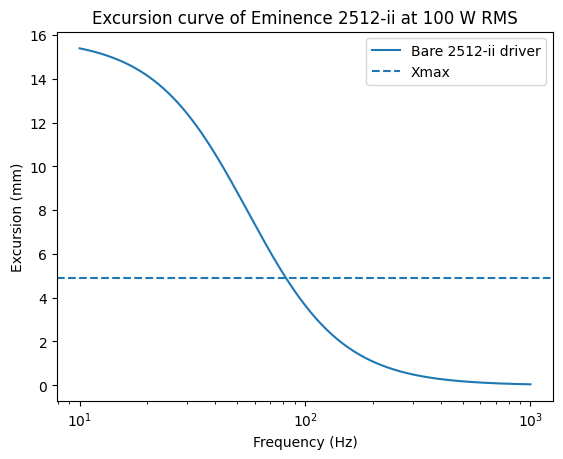

In [67]:
fa = np.logspace(1, 3, 1000)
wa = 2*np.pi*fa

def excursion_curve(em_params, ax, verbose = False, label = ''):
    '''
    First, substitute the EM parameters into the excursion function. This
    results in an expression that's purely a function of omega. It's ugly,
    but not meant to be readable.
    '''
    xfunc_sp = x_driver.subs(em_params)
    if verbose:
        display(xfunc_sp)
    '''
    Next, convert into a numpy function, for speedy computation. If you've
    got a decent computer, you'll notice that doing all of this math symbolically
    is barely slowing down the computation at all.
    '''
    xfunc_np = sp.lambdify(omega, xfunc_sp, 'numpy')
    '''
    Finally, plot it.
    '''
    ax.semilogx(fa, np.abs(xfunc_np(wa))*1000, label=label)
    last_line = ax.get_lines()[-1]
    last_line_color = last_line.get_color()
    ax.axhline(em_params['X_max']*1000, color=last_line_color, linestyle='--', label = 'Xmax')
    ax.set_ylabel('Excursion (mm)')
    ax.legend()
    
if __name__ == '__main__':
    excursion_curve(em_params, plt.gca(), label = 'Bare 2512-ii driver')
    plt.title('Excursion curve of Eminence 2512-ii at ' + str(em_params['P_in_rms']) + ' W RMS')
    plt.xlabel('Frequency (Hz)')
    plt.show()

## Impedance curve for the bare driver

Same basic schtick.

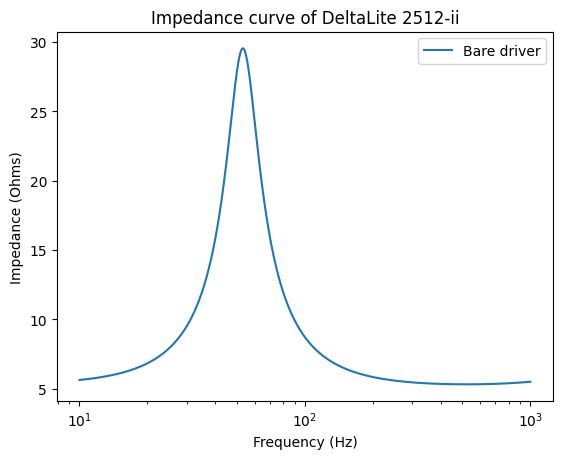

In [68]:
def impedance_curve(em_params, ax, label = ''):
    zfunc_sp = z_driver.subs(em_params)
    zfunc_np = sp.lambdify(omega, zfunc_sp, 'numpy')
    zabs = np.abs(zfunc_np(wa))
    ax.semilogx(fa, zabs, label = label)
    ax.set_ylabel('Impedance (Ohms)')
    ax.legend()

if __name__ == '__main__':
    impedance_curve(em_params, plt.gca(), label = 'Bare driver')
    plt.xlabel('Frequency (Hz)')
    plt.title('Impedance curve of DeltaLite 2512-ii')
    plt.show()

# Modeling the sealed box

Excursion of the cone changes the volume inside the box, and thus its pressure. In turn, pressure imparts a force on the cone. This restoring force, proportional to displacement, works exactly like the restoring force of the suspension. First, the change of volume...

$S_d$ is the frontal area of a single driver.

In [69]:
dV = (S_d)*X
displayEq('dV', dV)

<IPython.core.display.Math object>

... resulting in a change of pressure. Some details are given here. I've borrowed the equation for adiabatic compression, and expressed it in this way:

$P = P_{atm}(\dfrac {V}{V_{box}})^{\gamma}$

where $P_atm$ is the atmospheric pressure and $\gamma$ is a thermodynamic constant equal to roughly 1.4 for air. And making an approximation:

$\Delta P = \Delta V \dfrac {dP}{dV}$

Thus, $\Delta P = \Delta V \dfrac {P_{atm} \gamma}{V_{box}}$

However, the constants $\gamma P_{atm}$ can be replaced by $\rho c^2$ where $\rho$ is the density of air and $c$ is the speed of sound in air. I'm using $\rho c^2$ because they were already introduced in the section on the Thiele-Small parameters.

https://en.wikipedia.org/wiki/Adiabatic_process

https://en.wikipedia.org/wiki/Speed_of_sound

**The next equation here is where we introduce the number of drivers for the first time.**

I'm going to measure the pressure change based on a single driver pushing against the air in a fraction of the box volume determined by $V_{box}/N_d$. *Remember, if this gets confusing, set $N_d$ equal to 1 and ignore the number of drivers until you understand what's going on*.

In [70]:
dP = (gamma*P_atm*dV/(V_box/N_d)).subs(gamma*P_atm, c**2*rho)
displayEq('dP', dP)

<IPython.core.display.Math object>

... resulting in a force.

In [71]:
F_box = dP*S_d
displayEq('F_{box}', F_box)

<IPython.core.display.Math object>

What have we got here? A force that's proportional to displacement, just like a spring. Thus we can express the effect of the box as a *compliance* which is the reciprocal of the spring constant from physics class.

In [72]:
C_box = X/F_box

displayEq('C_{box}', C_box)

<IPython.core.display.Math object>

Now we can model the effect of the box. I've just combined the compliances of the driver and the box in parallel. You can see the benefit of the box. Below the resonant frequency, excursion remains roughly constant, which protects the driver from damage due to exceeding its mechanical limit. When we look at the SPL curve, we'll see that we've paid a price in low frequency extension, and gained a small but manageable "hump" in the curve.

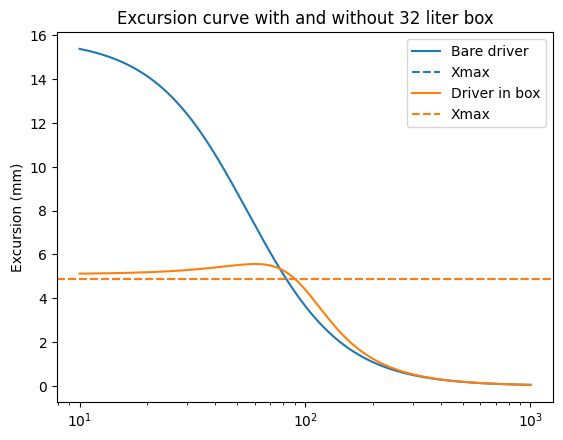

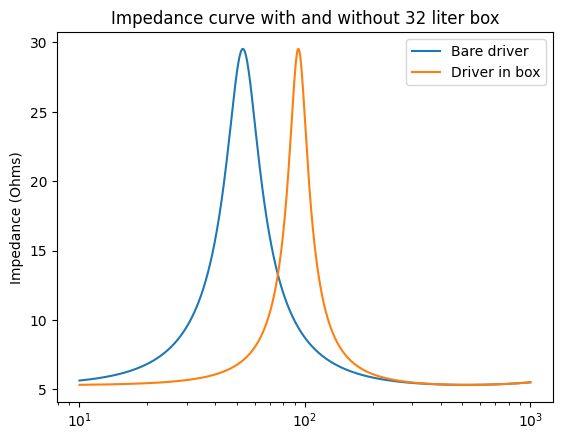

In [73]:
# deepcopy lets us modify em_box_params without changing the contents of em_params
em_box_params = copy.deepcopy(em_params)
em_box_params[C_ms] = 1/(1/em_params[C_ms] + 1/(C_box.subs(driver_params)))
if __name__ == '__main__':
    excursion_curve(em_params, plt.gca(), label = 'Bare driver')
    excursion_curve(em_box_params, plt.gca(), label = 'Driver in box')
    plt.title('Excursion curve with and without 32 liter box')
    plt.show()
    impedance_curve(em_params, plt.gca(), label = 'Bare driver')
    impedance_curve(em_box_params, plt.gca() ,label = 'Driver in box')
    plt.title('Impedance curve with and without 32 liter box')
    plt.show()

# Acoustical output

**This is where the number of drivers comes back in.**

I've found this reference, from a set of acoustics lecture notes. The author derives the "far field" response of a perfect piston radiator in an infinite baffle.

https://jontallen.ece.illinois.edu/uploads/473.F18/Lectures/Chapter_7b.pdf

The equation on p. 23 is:

$p(r, \Theta, t) = \dfrac {j \omega \rho_0 a^2 U_o}{2r}$

$e^{j(\omega t - kr)}$

$\dfrac {2 J_1(ka \sin \Theta)}{ka \sin \Theta}$

I'm only interested in the amplitude of $p$,

$P(r) = \dfrac {j \omega \rho a^2 U_o}{2r}$

$U_o$ = Linear velocity of the radiator

$a$ = Radius of cone

$r$ = Distance to listening position

Converting to our symbol convention, we're left with:

$P = \dfrac {\omega^2 \rho N_d S_d X}{2 \pi r}$

Note that P is an amplitude, not an average power. My SPL formula includes a factor of $1/\sqrt 2$ for this reason.

Further conversion to a dB scale requires a reference pressure. The conventional value is $P_{ref} = 20 \mu Pa$. And pressure is an amplitude not a power, so we multiply the log by 20:

$SPL = 20 \log_{10}(P/P_{ref})$.

Because the logarithm produces a dimensionless number, you always want to specify an input power and distance for your SPL, such as:

$SPL @ 1W @ 1m$

or voltage:

$SPL @ 2.83 V RMS @ 1m$

Being careless with units turns physics units into marketing units, just saying.

<IPython.core.display.Math object>

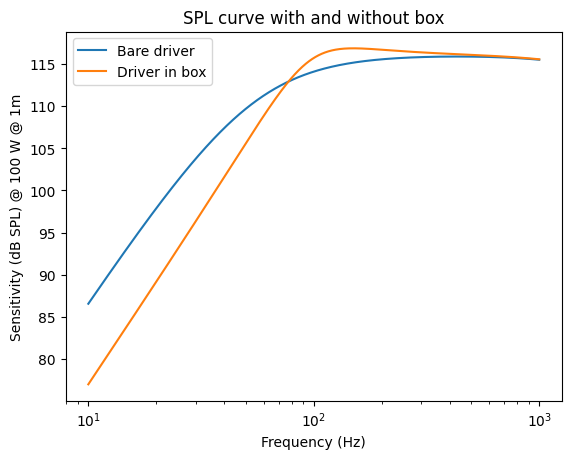

In [74]:
P_ratio = x_driver*omega**2*rho*N_d*S_d/2/sp.pi/R_ref/P_ref/sp.sqrt(2)
displayEq('P_{ratio}', P_ratio)

def sensitivity_curve(em_params, ax, label = ''):
    pfunc_sp = P_ratio.subs(em_params)
    pfunc_np = sp.lambdify(omega, pfunc_sp, 'numpy')
    pabs = np.abs(pfunc_np(wa))
    pabs_db = 20*np.log10(pabs)
    ax.semilogx(fa, pabs_db, label = label)
    ax.legend()

if __name__ == '__main__':
    sensitivity_curve(em_params, plt.gca(), 'Bare driver')
    sensitivity_curve(em_box_params, plt.gca(), 'Driver in box')
    plt.title('SPL curve with and without box')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Sensitivity (dB SPL) @ ' + str(em_params['P_in_rms']) + ' W @ 1m')
    plt.show()

# How the port works

This is unfortunately a lengthy, complicated derivation. I think the engineering approach is simpler, using lumped parameter diagrams, but I'm committed to doing it algebraically. There's no turning back!

## Overall strategy

1. Treat the displacement of the cone as the driving "input" to the system. My goal will be to compute the opposing force on the cone caused by coupling with the port.

2. Treat the air mass in the port as a mass on a spring, where the spring comes from a change of pressure in the box as the air mass is displaced. This gives the port a resonant frequency.

3. Write two equations of motion for the force on the cone and port air mass as functions of cone and port displacement.

4. These are a system of two equations in two variables. Solve them simultaneously (letting sympy do the work).

5. Now the force on the cone is known. Force divide by displacment is a frequency dependent spring constant that replaces the single valued spring constant of the sealed box.

6. Now the relationship between cone and port excursion is known, and they can be summed to compute the total acoustical output of the ported system.

## Derivation

Introducing the symbols:

$S_d$ = Frontal area of cone(s)

$S_p$ = Frontal area of port

$x$ = Displacement of the cone.

$x_p$ = Displacement of the "slug" of air inside the port

$m_{ms}$ = Mass of cone

$m_p$ = Mass of air inside the port

The port air mass is modeled as a piston, just as the cone is. The total change of volume is equal to the sum of the volumes displaced by the cone and the port:

In [75]:
dV = S_port/N_d*X_port + S_d*X

displayEq('dV', dV)

<IPython.core.display.Math object>

Change in pressure within the box. My previous derivation by hand used $\gamma P_{atm}$, so I'll make the substitution here.

In [76]:
dP = sp.expand(-gamma*P_atm*dV/(V_box/N_d)).subs(gamma*P_atm, c**2*rho)

displayEq('dP', dP)

<IPython.core.display.Math object>

Equation for the force on the cone from the pressure in the box

In [77]:
eq1 = sp.Eq(F_cone, sp.expand(dP*S_d))

eq1

Eq(F_cone, -N_d*S_d**2*X*c**2*rho/V_box - S_d*S_port*X_port*c**2*rho/V_box)

I'm going to anticipate the progress of this derivation, based on having done it by hand in the past. I'll define $m_p$ in terms of the port resonant frequency. This is mainly aesthetic, to make the equations look more symmetrical. But also, the resonant frequency is typically what you plug into a speaker design program.

In [78]:
m_port = (gamma*P_atm*(S_port)**2/(V_box)/w_port**2).subs(gamma*P_atm, c**2*rho)

displayEq('m_{port}', m_port)

<IPython.core.display.Math object>

Equation for the force on the port, including the inertial force on the port mass, where the mass will be defined as above.

In [79]:
eq2 = sp.Eq(0, sp.expand(omega**2*X_port*m_port + dP*S_port))

eq2

Eq(0, -N_d*S_d*S_port*X*c**2*rho/V_box + S_port**2*X_port*c**2*omega**2*rho/(V_box*w_port**2) - S_port**2*X_port*c**2*rho/V_box)

These are two equations in two variables, can be solved for the cone and port motion

In [80]:
result = sp.solve([eq1, eq2], [X, X_port])

displayEq('X_{cone}', result[X])
displayEq('X_{port}', result[X_port])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Displacement divided by force is a compliance. This compliance can be added in parallel to the cone compliance.

For a bit more explanation, a compliance is the reciprocal of a spring constant. If this were expressed as a spring constant, it would represent how much extra resistance the cone "feels" because of the port on the other side of the box.

In [81]:
C_ported = sp.simplify(-result[X]/F_cone)

displayEq('C_{ported}', C_ported)

<IPython.core.display.Math object>

Isolate the relationship between the cone and port excursions.

*See that the box volume has dropped out. The cone only "cares" about the port tuning frequency!*

In [82]:
port_cone_frac = sp.simplify(result[X_port]/result[X])

displayEq('X_{port}/X', port_cone_frac)

<IPython.core.display.Math object>

Defining a symbol 

$\kappa = \dfrac {\omega^2}{\omega^2 - \omega_p^2}$, 

compute the total displacement volume 

$S_d x + S_{port} x_{port}$, 

which produces the outgoing acoustic wavefront.

In [83]:
kappa = omega**2/(omega**2 - w_port**2)
displayEq(r'\kappa', kappa)

<IPython.core.display.Math object>

## Excursion curve for ported system

Now we get to see if the simulation still works. First, we need to fill in the new parameters added to the model: The port tuning frequency and box volume.

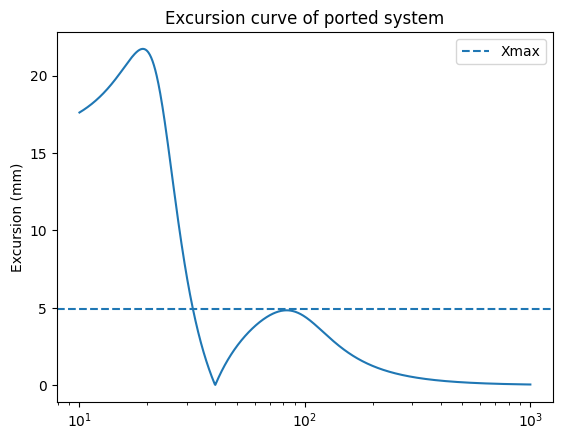

In [84]:
def build_ported_params(em_params, f_port_hz):
    em_params[w_port] = sp.N(f_port_hz*2*sp.pi)
    em_ported_params = copy.deepcopy(em_params)
    em_ported_params[C_ms] = 1/(1/em_params[C_ms] + 1/C_ported.subs(em_params))
    lport = m_port/rho/S_port - sp.sqrt(4*S_port/sp.pi)*em_ported_params[end_correct]
    em_ported_params[L_port_m] = sp.N(lport.subs(em_ported_params))
    return em_ported_params

em_ported_params  = build_ported_params(em_params, 40)
if __name__ == '__main__':
    excursion_curve(em_ported_params, plt.gca())
    plt.title('Excursion curve of ported system')
    plt.show()


## SPL curve for ported system

In [85]:
pressure_factor = rho*S_d*N_d/2/sp.pi/R_ref/P_ref/sp.sqrt(2)
displayEq('Pressure factor', pressure_factor)


<IPython.core.display.Math object>

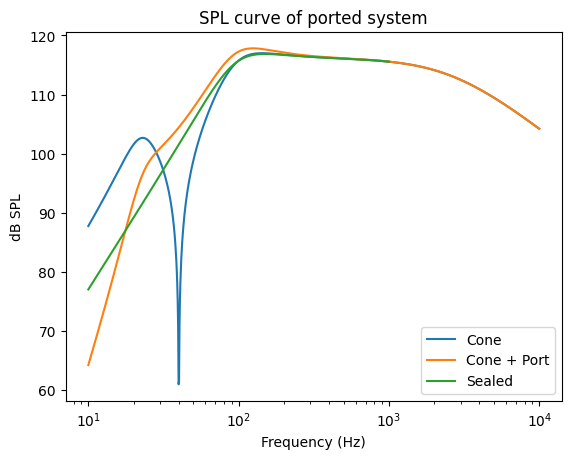

In [86]:

def sensitivity_curve_ported(em_params, ax, label, show_cone = False, logscale = False):

    fa = np.logspace(1, 4, 1000)
    wa = 2*np.pi*fa

    P_driver_ratio = pressure_factor*omega**2*x_driver
    pfunc_sp = P_driver_ratio.subs(em_params)
    pfunc_np = sp.lambdify(omega, pfunc_sp, 'numpy')
    pabs = np.abs(pfunc_np(wa))
    pabs_db = 20*np.log10(pabs)
    
    P_total_ratio = pressure_factor*omega**2*x_driver*kappa
    ptotalfunc_sp = P_total_ratio.subs(em_params)
    ptotalfunc_sp = sp.lambdify(omega, ptotalfunc_sp, 'numpy')
    ptotalabs = np.abs(ptotalfunc_sp(wa))
    ptotalabs_db = 20*np.log10(ptotalabs)
    if logscale:
        ax.plot(np.log10(fa), ptotalabs_db, label = label)
        if show_cone:
            ax.plot(np.log10(fa), pabs_db, label = 'Cone')
    else:
        if show_cone:
            ax.semilogx(fa, pabs_db, label = 'Cone')
        ax.semilogx(fa, ptotalabs_db, label = label)
    ax.set_ylabel('dB SPL')
    ax.legend()

if __name__ == '__main__':
    sensitivity_curve_ported(em_ported_params, plt.gca(), label = 'Cone + Port', show_cone = True)
    sensitivity_curve(em_box_params, plt.gca(), 'Sealed')
    plt.title('SPL curve of ported system')
    plt.xlabel('Frequency (Hz)')
    plt.show()


## Comparison to WinISD

The ultimate scientific test of a theory would be a comparison to measured data. But... *acoustical measurement is hard*.

However, given that the theory of spekers is quite well established, a good Plan B would be to compare my theory to other representations of the theory, including available modeling software. Here, I'm ignoring the fact that the free software is not completely uncontroversial. But let's see what happens.

I entered the same design into the latest version of WinISD Pro. I had to make one change, because WinISD computes the input voltage differently. Where I compute $V = \sqrt {P\cdot Z_{nom}}$, WinISD uses $V = \sqrt {P\cdot R_e}$. To compensate for this, I entered 100 Watts into this notebook, and 151.5 Watts into WinISD, so that both models are using the same voltage.

What's to learn from this comparison: *Two people, myself and the authors of WinISD, have followed completely different routes to the same answer.* That's a pretty good validation of both answers. It would be hard for the plots to match this well if either of us had made some kind of conceptual mistake.

Now it's worth pointing out that while we probably made no conceptual mistakes, both models are based on assumptions that are worth re-iterating:

**This is a small-signal model**, and neglects geometric effects such a "beaming," so it's probably only appropriate for frequencies up to about 300 Hz. But that's the typical subject matter of bass speaker design, where the box affects performance.

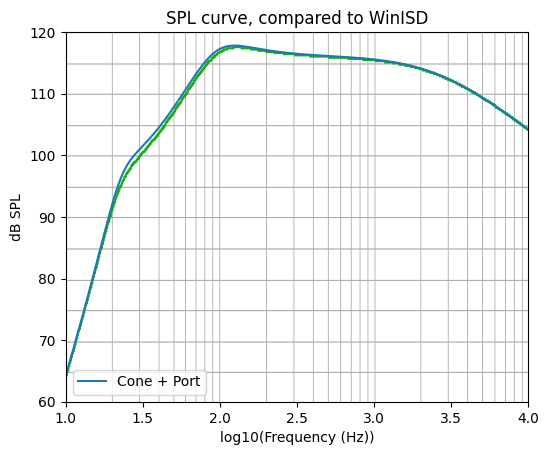

In [87]:
if __name__ == '__main__':
    img = plt.imread("img/spl_background_2.png")
    plt.imshow(img, extent=[1, 4, 60, 120], aspect = 0.04)
    sensitivity_curve_ported(em_ported_params, plt.gca(), label = 'Cone + Port', show_cone = False, logscale = True)
    plt.xlabel('log10(Frequency (Hz))')
    plt.title('SPL curve, compared to WinISD')

## Impedance curve of ported system

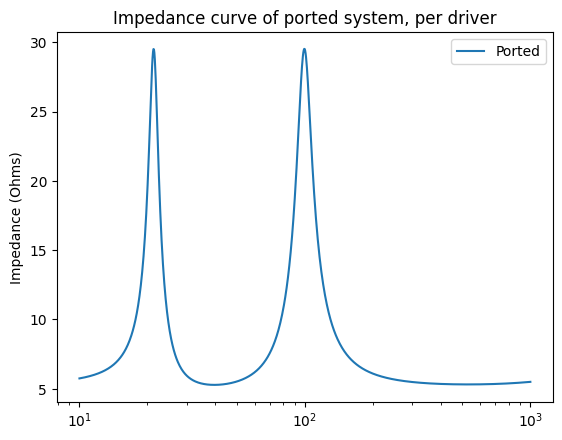

In [88]:
if __name__ == '__main__':    
    impedance_curve(em_ported_params, plt.gca(), label = 'Ported')
    plt.title('Impedance curve of ported system, per driver')
    plt.show()

## Port air speed

**The number of drivers comes back in here!**

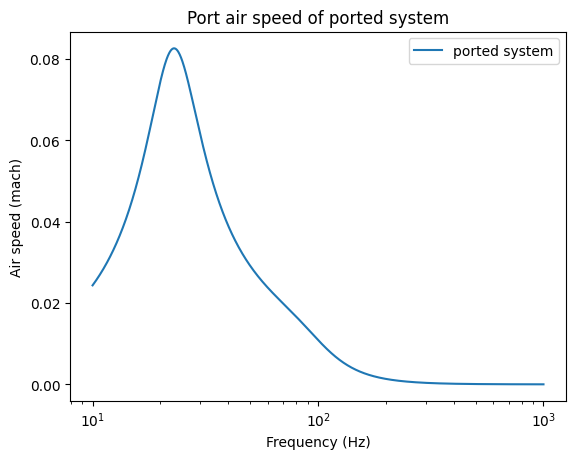

In [89]:
def airspeed_curve_ported(em_params, ax, label, verbose = False):
    vfunc_sp = (1j*omega*x_driver*port_cone_frac/c).subs(em_params)
    if verbose:
        displayEq('v_{func}', vfunc_sp)
    vfunc_np = sp.lambdify(omega, vfunc_sp, 'numpy')
    vabs = np.abs(vfunc_np(wa))
    ax.semilogx(fa, vabs, label = label)
    ax.set_ylabel('Air speed (mach)')
    ax.legend()

if __name__ == '__main__':
    airspeed_curve_ported(em_ported_params, plt.gca(), 'ported system')
    plt.title('Port air speed of ported system')
    plt.xlabel('Frequency (Hz)')
    plt.show()

## Transient response

**This section is experimental, and needs a bunch of validation**

/tmp/ipykernel_590763/3368670175.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


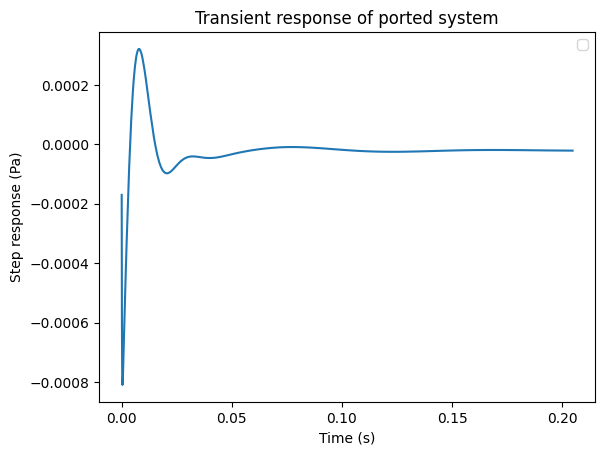

In [90]:
def transient_response_ported(em_params, ax, mul = 1, label = ''):
    fa = np.linspace(0, 20000, 4096)
    wa = 2*np.pi*fa
  
    kappa = (omega**2/(omega**2 - w_port**2))
    P_total = (omega**2*rho*S_d*N_d/2/sp.pi/R_ref*x_driver*kappa).subs(em_params)
    ptotalfunc_sp = sp.lambdify(omega, P_total, 'numpy')
    ptotal = ptotalfunc_sp(wa)*mul

    # Assume ptotal is your frequency response (complex), and w is the angular frequency array (rad/s)
    # Example: w = np.linspace(0, w_max, N)
    # ptotal = ... (complex array, same length as w)

    # Inverse FFT assumes evenly spaced frequency points and covers 0 to Nyquist

    # Compute time axis    
    N = len(ptotal)
    dw = wa[1] - wa[0]
    T = 2 * np.pi / dw  # total time duration
    t = np.linspace(0, T, N, endpoint=False)
    ptotal_full = np.concatenate([ptotal, np.conj(ptotal[-2:0:-1])])
    impulse_response = (np.fft.ifft(ptotal_full).real)[:N]

    # Step response is cumulative sum (integral) of impulse response
    step_response = np.cumsum(impulse_response) * (t[1] - t[0])
    if mul == 1:
        label1 = label
    else:
        label1 = label + ' *' + str(mul)
    ax.plot(t, step_response, label = label1)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Step response (Pa)')
    ax.legend()

if __name__ == '__main__':
    transient_response_ported(em_ported_params, plt.gca())
    plt.title('Transient response of ported system')
    plt.xlabel('Time (s)')
    plt.show()

## Port length, crudely

There are more detailed port length calculators, that take the "end effects" of the port into account. I'm going to leave those for now, and look strictly at the air mass inside the port, which has this volume:

In [91]:
V_port = m_port/rho
displayEq('V_{port}', V_port)

<IPython.core.display.Math object>

Thus the length is the volume divided by the area. But the effective air mass moved by the port is slightly longer than the port itself, an end correction factor times the port diameter. I'll model the port diameter as $D = \sqrt{4 S_{port}/\pi}$

In [92]:
L_port = V_port/S_port - end_correct*sp.sqrt(4*S_port/sp.pi)
displayEq('L_{port}', L_port)

<IPython.core.display.Math object>

... and we can hang some numbers on it, in meters of course:

In [93]:
displayEq('L_{port}', sp.N(L_port.subs(em_ported_params)))

<IPython.core.display.Math object>

# Appendices

## Conversion of formulas to Javascript

I've tried a few different approaches to writing my online modeling program. I tried Python, using the **flet** package, but it generates a gigantic pile of files, takes forever to load on the user's machine, and it seems every new version causes my program to break when I try to rebuild it. I'll just say it, that creating small web apps in Python isn't worthwhile.

I also tried Javascript, but it has the inconvenience of lacking good math support, such as an exponentiation operator and complex arithmetic.

Then I learned that **sympy** can print formulas in Javascript syntax. This led me to try writing the online modeling program in Javascript, but with automatically generated math formulas. The following cells generate the formulas that my Javascript program needs, and automatically writes them to a file.

Formulas that are real-valued can just be translated directly. And I've arranged things so that there's only one complex-valued formula: For cone excursion.

In [94]:
# Box compliance for sealed system. Note that this is always real valued
C_box

V_box/(N_d*S_d**2*c**2*rho)

In [95]:
# This is the effective compliance for a sealed system
C_eff_sealed = 1/(1/C_ms + 1/C_box)
displayEq('C_{eff, sealed}', C_eff_sealed)

<IPython.core.display.Math object>

In [96]:
# Likewise, box compliance for a ported system
C_ported

V_box*(omega**2 - w_port**2)/(N_d*S_d**2*c**2*omega**2*rho)

In [97]:
# The effective compliance for a ported system
C_eff_ported = 1/(1/C_ms + 1/C_ported)
displayEq('C_{eff, ported}', C_eff_ported)

<IPython.core.display.Math object>

In [98]:
# Relationship between port and cone displacement. Note that this is always real valued
port_cone_frac

N_d*S_d*w_port**2/(S_port*(omega**2 - w_port**2))

In [99]:
# Conversion to sound pressure at distance r
sound_pressure_ratio = omega**2*rho*S_d/2/sp.pi/R_ref/P_ref
sound_pressure_ratio

S_d*omega**2*rho/(2*pi*P_ref*R_ref)

In [100]:
# Excursion formula with voltage set to 1, so my Javascript program can apply two different input voltages.
x_driver_z = x_driver.subs({Z_e: R_e + 1j*omega*L_e, V: 1})
x_squared_real = sp.expand(x_driver_z*sp.conjugate(x_driver_z)).subs(C_ms, C_eff)

In [101]:
from sympy.printing.jscode import jscode

# Code for turning this notebook into an import-able Python library
if __name__ == '__main__':
    if input('OK to generate Javascript code? (y/n)') == 'y':
        outf = open('speakerjs/generated_code.js', 'w')
        def printJs(label, expr, dprint = False):
            if dprint:
                print(label + ' = dprint("' + label + ' = ",' + jscode(expr) + ')', file = outf)
            else:
                print(label + ' = ' + jscode(expr), file = outf)
        print('function generated_code_1() {', file = outf)
        printJs('C_ms', params[0], dprint = True)
        printJs('M_ms', params[1], dprint = True)
        printJs('R_ms', params[2], dprint = True)
        printJs('BL', params[3], dprint = True)
        printJs('P_ref', P_ref.subs(em_params), dprint = True)
        printJs('R_ref', R_ref.subs(em_params), dprint = True)
        print('}', file = outf)
        print('function generated_code_2(omega) {', file = outf)
        # printJs('omega', 2*sp.pi*f)
        printJs('C_eff_sealed', C_eff_sealed)
        printJs('C_eff_ported', C_eff_ported)
        print('''if (Fport == 0) {
            C_eff = C_eff_sealed
            }
            else {
            C_eff = C_eff_ported
            }
            V = VinExc''', file = outf)
        printJs('x_squared_real', x_squared_real)
        print('xabs = Math.sqrt(x_squared_real)', file = outf)
        printJs('port_cone_frac', port_cone_frac)
        printJs('sound_pressure_ratio', sound_pressure_ratio)
        print('}', file = outf)
        outf.close()

## Generation of tabular report

In [102]:
def report_table(system_list, header_list, format_fun = lambda x: x):
    report_keys = ['Znom',
        'f_s',
        w_s,
        R_e,
        L_e,
        Q_ms,
        Q_es,
        V_as,
        'X_max',
        S_d,
        rho,
        c,
        'P_in_rms',
        R_ref,
        P_ref,
        V,
        'Q_ts',
        #C_ms,
        M_ms,
        R_ms,
        BL,
        C_ms_driver,
        V_box,
        f_port,
        S_port,
        L_port_m,
        'L_port_in']
    for system in system_list:
        system['L_port_in'] = system[L_port_m]/0.0254
    df = pd.DataFrame([[tag] + [format_fun(system[tag]) for system in system_list] for tag in report_keys])
    df.columns = ['Parameter'] + header_list
    return df

## Generation of Python library

In [103]:
# Code for turning this notebook into an import-able Python library
if __name__ == '__main__':
    if input('OK to generate Python library? (y/n)') == 'y':
        !python3 -m jupyter nbconvert --to python ./speakerTheorySympy.ipynb

[NbConvertApp] Converting notebook ./speakerTheorySympy.ipynb to python
[NbConvertApp] Writing 43055 bytes to speakerTheorySympy.py


## Generation of PDF document

In [ ]:
# Code for converting this document to HTML
if __name__ == '__main__':
    if input('OK to generate PDF (probably not unless you just saved the notebook)? (y/n)') == 'y':
        !python3 -m jupyter nbconvert --to pdf ./speakerTheorySympy.ipynb